### Step-1 Imports

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

import matplotlib.pyplot as plt

### Step-2 Load Datasets

In [3]:
data = load_breast_cancer()

X = data.data
y = data.target

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (569, 30)
y shape: (569,)


### Step-3 Train/Test, Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Step-4 Feature Scaling

In [5]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Step 5 — Convert to PyTorch Tensors

In [6]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

### Step 6 — Build Neural Network

In [7]:
class NeuralNetwork(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(30, 32),
            nn.ReLU(),

            nn.Linear(32, 16),
            nn.ReLU(),

            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.network(x)

### Step 7 — Create Model

In [8]:
model = NeuralNetwork()

print(model)

NeuralNetwork(
  (network): Sequential(
    (0): Linear(in_features=30, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=1, bias=True)
  )
)


### Step 8 — Loss and Optimizer

In [9]:
criterion = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

### Step-9 Training

In [10]:
epochs = 100

train_losses = []

for epoch in range(epochs):

    # Forward pass
    outputs = model(X_train).squeeze()

    # Calculate loss
    loss = criterion(outputs, y_train)

    # Clear old gradients
    optimizer.zero_grad()

    # Backpropagation
    loss.backward()

    # Update weights
    optimizer.step()

    train_losses.append(loss.item())

    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch [{epoch+1}/{epochs}], "
            f"Loss: {loss.item():.4f}"
        )

Epoch [10/100], Loss: 0.6320
Epoch [20/100], Loss: 0.5744
Epoch [30/100], Loss: 0.5001
Epoch [40/100], Loss: 0.4121
Epoch [50/100], Loss: 0.3236
Epoch [60/100], Loss: 0.2467
Epoch [70/100], Loss: 0.1880
Epoch [80/100], Loss: 0.1476
Epoch [90/100], Loss: 0.1203
Epoch [100/100], Loss: 0.1017


In [11]:
model.eval()

with torch.no_grad():
    logits = model(X_test).squeeze()
    probabilities = torch.sigmoid(logits)

    predictions = (probabilities >= 0.5).float()

In [12]:
predictions = predictions.numpy()
y_true = y_test.numpy()

In [13]:
accuracy = accuracy_score(
    y_true,
    predictions
)

print("Accuracy:", accuracy)

Accuracy: 0.9736842105263158


In [14]:
print(
    classification_report(
        y_true,
        predictions
    )
)

              precision    recall  f1-score   support

         0.0       0.98      0.95      0.96        42
         1.0       0.97      0.99      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



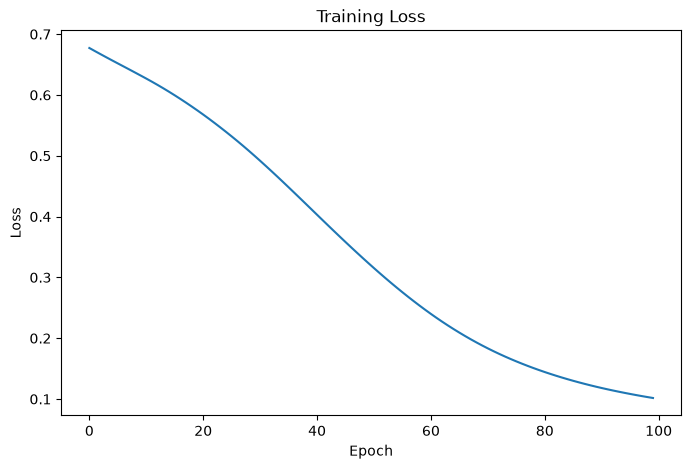

In [15]:
plt.figure(figsize=(8, 5))

plt.plot(train_losses)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")

plt.show()

In [16]:
torch.save(
    model.state_dict(),
    "breast_cancer_model.pth"
)

In [17]:
import joblib

joblib.dump(
    scaler,
    "scaler.pkl"
)

['scaler.pkl']